In [3]:
import kagglehub

kagglehub.login()

In [6]:
path = kagglehub.competition_download('house-prices-advanced-regression-techniques')
print(path)

100%|██████████| 199k/199k [00:00<00:00, 246kB/s]

Extracting files...
C:\Users\Areeb Sajids\.cache\kagglehub\competitions\house-prices-advanced-regression-techniques


In [7]:
# =============================================================================
# CELL 1: Imports & Global Configuration
# =============================================================================
# Standard Library
import warnings
import os
import sys
from pathlib import Path

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Scikit-Learn — The ML Swiss Army Knife
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# XGBoost — Industry-standard Gradient Boosting
import xgboost as xgb

# Model Persistence
import joblib

# Suppress non-critical warnings for cleaner output
warnings.filterwarnings("ignore")

# ── Aesthetic Configuration ──────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = {
    "primary":   "#2563EB",   # Blue
    "secondary": "#10B981",   # Green
    "accent":    "#F59E0B",   # Amber
    "danger":    "#EF4444",   # Red
    "dark":      "#1E293B",   # Slate Dark
    "light":     "#F1F5F9",   # Slate Light
}

# ── Path Configuration ───────────────────────────────────────────────────────
BASE_DIR    = Path(".")
DATA_RAW    = BASE_DIR / "data" / "raw" / "train.csv"
DATA_PROC   = BASE_DIR / "data" / "processed"
MODELS_DIR  = BASE_DIR / "models"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

for d in [DATA_PROC, MODELS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully.")
print(f"   Python  : {sys.version.split()[0]}")
print(f"   NumPy   : {np.__version__}")
print(f"   Pandas  : {pd.__version__}")
print(f"   XGBoost : {xgb.__version__}")

✅ All libraries imported successfully.
   Python  : 3.12.12
   NumPy   : 2.4.4
   Pandas  : 3.0.2
   XGBoost : 3.2.0


  Dataset Shape   : 1,460 rows × 81 columns
  Memory Usage    : 3516.4 KB


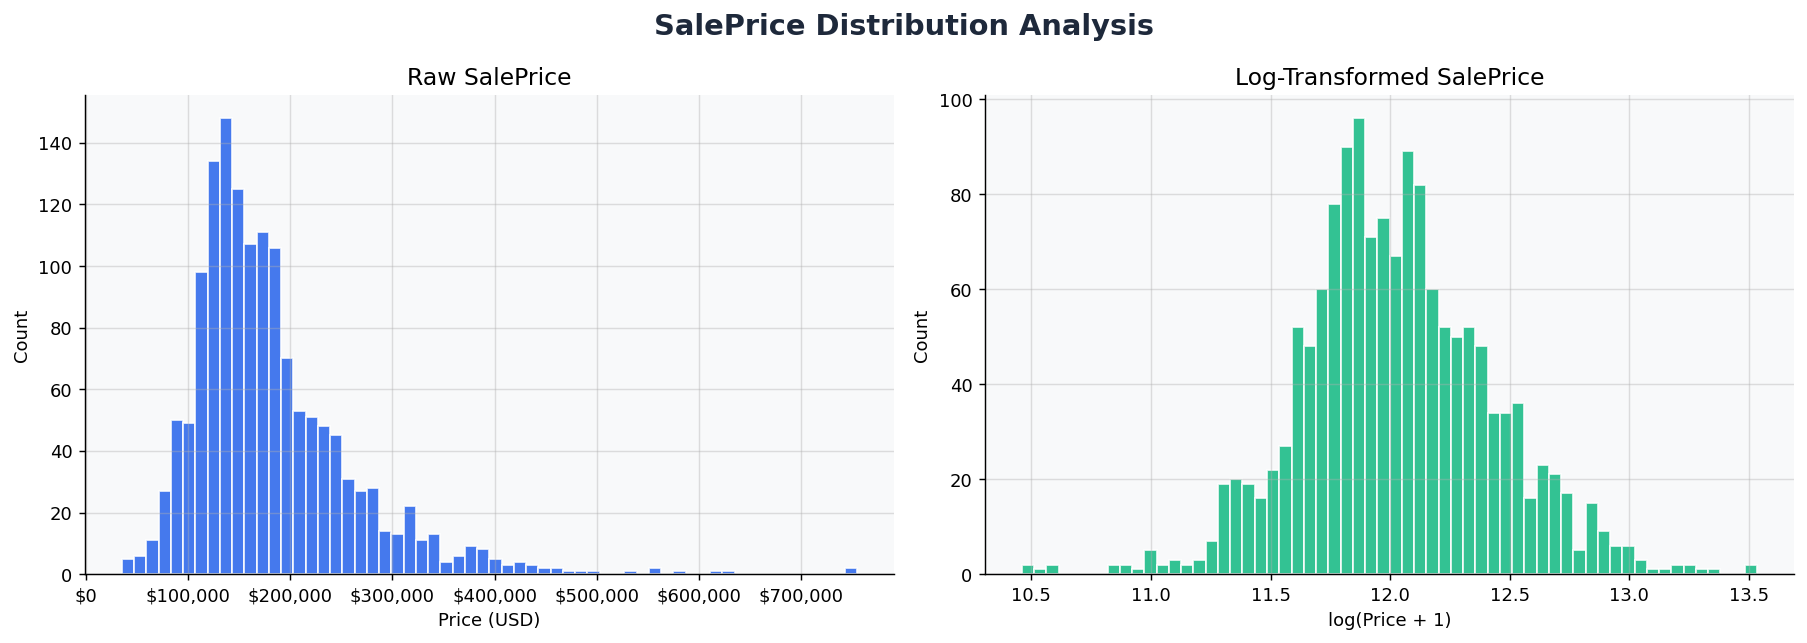


📊 SalePrice Statistics:
count      $1,460
mean     $180,921
std       $79,443
min       $34,900
25%      $129,975
50%      $163,000
75%      $214,000
max      $755,000
Name: SalePrice, dtype: str

⚠️  Columns with missing values: 19
     Feature  Missing_Count  Missing_Pct
      PoolQC           1453        99.52
 MiscFeature           1406        96.30
       Alley           1369        93.77
       Fence           1179        80.75
  MasVnrType            872        59.73
 FireplaceQu            690        47.26
 LotFrontage            259        17.74
  GarageType             81         5.55
 GarageYrBlt             81         5.55
GarageFinish             81         5.55
  GarageQual             81         5.55
  GarageCond             81         5.55
BsmtExposure             38         2.60
BsmtFinType2             38         2.60
    BsmtQual             37         2.53
    BsmtCond             37         2.53
BsmtFinType1             37         2.53
  MasVnrArea              8 

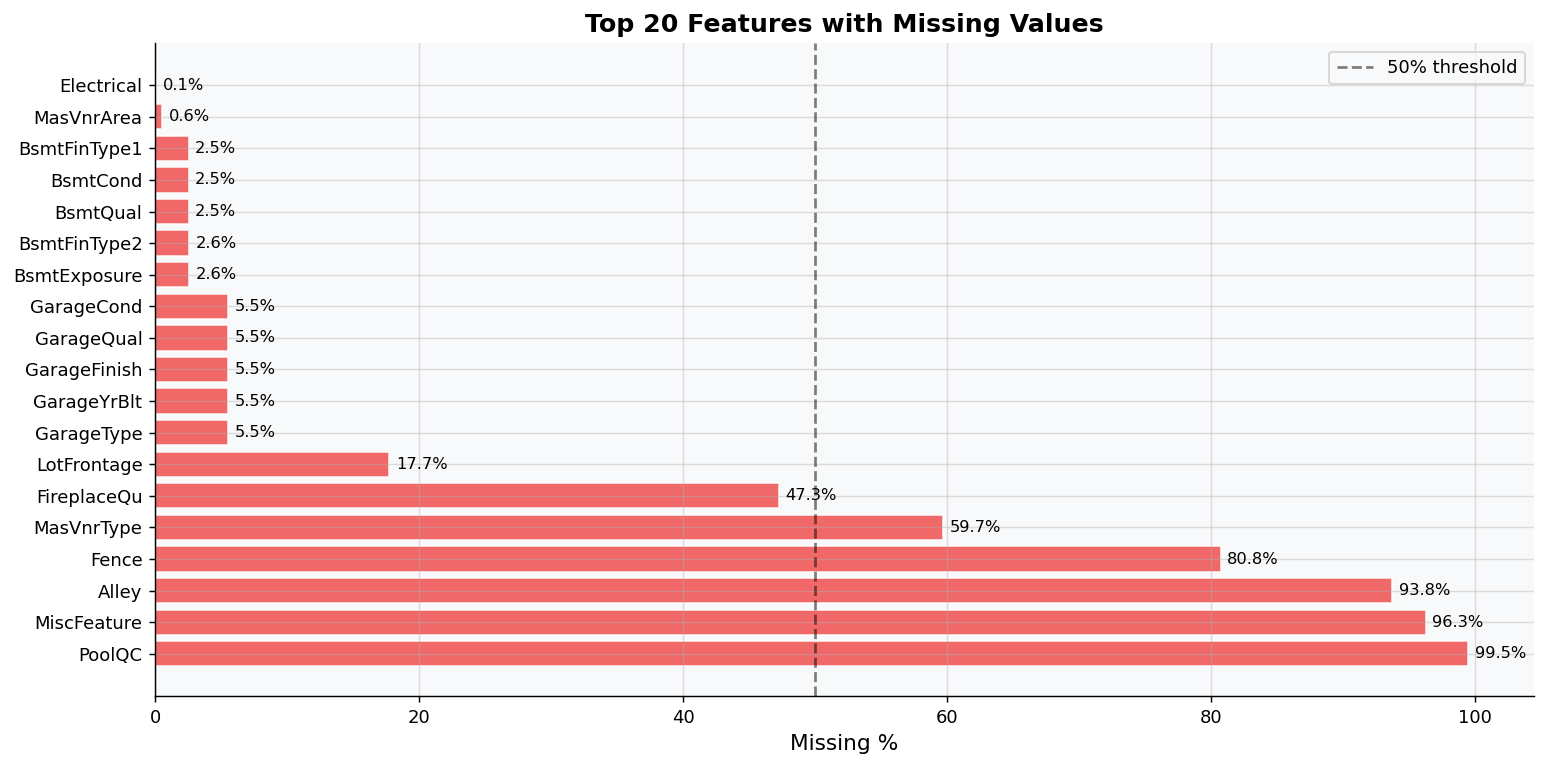

In [8]:
# CELL 2: Data Loading & Exploratory Data Analysis (EDA)
# =============================================================================

df = pd.read_csv(DATA_RAW)

print("=" * 60)
print(f"  Dataset Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory Usage    : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print("=" * 60)

# ── Target Variable Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SalePrice Distribution Analysis", fontsize=16, fontweight="bold", color=PALETTE["dark"])

# Raw distribution
axes[0].hist(df["SalePrice"], bins=60, color=PALETTE["primary"], edgecolor="white", alpha=0.85)
axes[0].set_title("Raw SalePrice", fontsize=13)
axes[0].set_xlabel("Price (USD)")
axes[0].set_ylabel("Count")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

# Log-transformed distribution
axes[1].hist(np.log1p(df["SalePrice"]), bins=60, color=PALETTE["secondary"], edgecolor="white", alpha=0.85)
axes[1].set_title("Log-Transformed SalePrice", fontsize=13)
axes[1].set_xlabel("log(Price + 1)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_saleprice_distribution.png", bbox_inches="tight")
plt.show()

print(f"\n📊 SalePrice Statistics:")
print(df["SalePrice"].describe().apply(lambda x: f"${x:,.0f}"))

# ── Missing Value Analysis ────────────────────────────────────────────────────
missing = (
    df.isnull().sum()
    .reset_index()
    .rename(columns={"index": "Feature", 0: "Missing_Count"})
    .query("Missing_Count > 0")
    .assign(Missing_Pct=lambda x: (x["Missing_Count"] / len(df) * 100).round(2))
    .sort_values("Missing_Pct", ascending=False)
    .reset_index(drop=True)
)

print(f"\n⚠️  Columns with missing values: {len(missing)}")
print(missing.head(20).to_string(index=False))

# Visualize missing values
fig, ax = plt.subplots(figsize=(12, 6))
top_missing = missing.head(20)
bars = ax.barh(top_missing["Feature"], top_missing["Missing_Pct"],
               color=PALETTE["danger"], alpha=0.8, edgecolor="white")
ax.set_xlabel("Missing %", fontsize=12)
ax.set_title("Top 20 Features with Missing Values", fontsize=14, fontweight="bold")
ax.axvline(x=50, color="black", linestyle="--", alpha=0.5, label="50% threshold")
ax.legend()
for bar, val in zip(bars, top_missing["Missing_Pct"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_missing_values.png", bbox_inches="tight")
plt.show()

In [9]:
# CELL 3: Data Cleaning
# =============================================================================

df_clean = df.copy()

# ── 1. Drop High-Missingness Columns (>80%) ───────────────────────────────────
HIGH_MISSING_THRESHOLD = 0.80
high_miss_cols = missing[missing["Missing_Pct"] > HIGH_MISSING_THRESHOLD]["Feature"].tolist()
df_clean.drop(columns=high_miss_cols, inplace=True)
print(f"🗑️  Dropped {len(high_miss_cols)} high-missingness columns: {high_miss_cols}")

# ── 2. Domain-Specific NA Fills ───────────────────────────────────────────────
# In this dataset, NA in many categorical columns means "None" (e.g., no garage)
# This is documented in the Kaggle data dictionary
categorical_na_means_none = [
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType", "FireplaceQu", "Fence", "MiscFeature",
]
for col in categorical_na_means_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("None")

# Numerical columns where NA means 0 (no feature = 0 area/value)
numerical_na_means_zero = [
    "GarageYrBlt", "GarageArea", "GarageCars",
    "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF",
    "BsmtFullBath", "BsmtHalfBath", "MasVnrArea",
]
for col in numerical_na_means_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# ── 3. Fill Remaining with Mode/Median ────────────────────────────────────────
remaining_cat_na = df_clean.select_dtypes(include="object").columns[df_clean.select_dtypes(include="object").isnull().any()]
for col in remaining_cat_na:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

remaining_num_na = df_clean.select_dtypes(include=[np.number]).columns[df_clean.select_dtypes(include=[np.number]).isnull().any()]
for col in remaining_num_na:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# ── 4. Remove Outliers ────────────────────────────────────────────────────────
# Kaggle's data notes suggest removing houses >4000 sqft with very low price
# These are anomalies that confuse the model
before = len(df_clean)
df_clean = df_clean[~((df_clean["GrLivArea"] > 4000) & (df_clean["SalePrice"] < 300_000))]
print(f"🔪 Removed {before - len(df_clean)} outliers (large area, low price anomalies)")

# ── 5. Fix Data Types ─────────────────────────────────────────────────────────
# MSSubClass is stored as int but is actually a categorical code
df_clean["MSSubClass"] = df_clean["MSSubClass"].astype(str)

print(f"\n✅ Cleaning complete.")
print(f"   Rows remaining  : {len(df_clean):,}")
print(f"   Missing values  : {df_clean.isnull().sum().sum()}")

🗑️  Dropped 17 high-missingness columns: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu', 'LotFrontage', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1']
🔪 Removed 2 outliers (large area, low price anomalies)

✅ Cleaning complete.
   Rows remaining  : 1,458
   Missing values  : 0


✅ Feature Engineering complete.
   New features added: TotalSF, TotalBaths, HouseAge, RemodAge,
                       WasRemodeled, HasGarage, HasBasement,
                       HasPool, HasFireplace, Has2ndFloor, QualCond


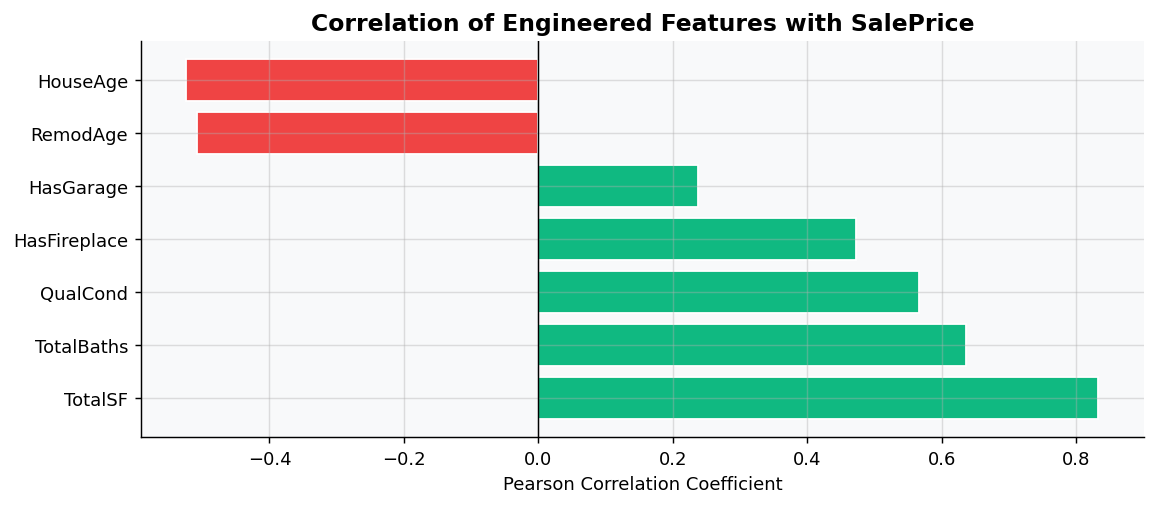

In [10]:
# CELL 4: Feature Engineering
# =============================================================================

df_feat = df_clean.copy()

# ── 1. Total Square Footage ────────────────────────────────────────────────────
# Buyers care about TOTAL livable space, not individual components
df_feat["TotalSF"] = (
    df_feat["TotalBsmtSF"] +
    df_feat["1stFlrSF"] +
    df_feat["2ndFlrSF"]
)

# ── 2. Total Bathrooms ────────────────────────────────────────────────────────
# Half baths = 0.5 full baths (toilet + sink only, no shower/tub)
df_feat["TotalBaths"] = (
    df_feat["FullBath"] +
    0.5 * df_feat["HalfBath"] +
    df_feat["BsmtFullBath"] +
    0.5 * df_feat["BsmtHalfBath"]
)

# ── 3. House Age & Remodel Age ────────────────────────────────────────────────
CURRENT_YEAR = 2010  # Dataset is from 2010
df_feat["HouseAge"]   = CURRENT_YEAR - df_feat["YearBuilt"]
df_feat["RemodAge"]   = CURRENT_YEAR - df_feat["YearRemodAdd"]
df_feat["WasRemodeled"] = (df_feat["YearRemodAdd"] != df_feat["YearBuilt"]).astype(int)

# ── 4. Has Features (Binary Flags) ───────────────────────────────────────────
df_feat["HasGarage"]   = (df_feat["GarageArea"] > 0).astype(int)
df_feat["HasBasement"] = (df_feat["TotalBsmtSF"] > 0).astype(int)
df_feat["HasPool"]     = (df_feat.get("PoolArea", pd.Series(0, index=df_feat.index)) > 0).astype(int)
df_feat["HasFireplace"]= (df_feat["Fireplaces"] > 0).astype(int)
df_feat["Has2ndFloor"] = (df_feat["2ndFlrSF"] > 0).astype(int)

# ── 5. Quality × Condition Interaction ───────────────────────────────────────
# A house with great quality AND great condition is worth much more
# This interaction captures non-linear relationships
df_feat["QualCond"]    = df_feat["OverallQual"] * df_feat["OverallCond"]

# ── 6. Log-Transform the Target ──────────────────────────────────────────────
df_feat["SalePrice_log"] = np.log1p(df_feat["SalePrice"])

print("✅ Feature Engineering complete.")
print(f"   New features added: TotalSF, TotalBaths, HouseAge, RemodAge,")
print(f"                       WasRemodeled, HasGarage, HasBasement,")
print(f"                       HasPool, HasFireplace, Has2ndFloor, QualCond")

# Correlation of new features with SalePrice
new_feats = ["TotalSF", "TotalBaths", "HouseAge", "RemodAge", 
             "QualCond", "HasGarage", "HasFireplace"]
corr_vals = df_feat[new_feats + ["SalePrice"]].corr()["SalePrice"].drop("SalePrice").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = [PALETTE["secondary"] if v > 0 else PALETTE["danger"] for v in corr_vals]
ax.barh(corr_vals.index, corr_vals.values, color=colors, edgecolor="white")
ax.set_title("Correlation of Engineered Features with SalePrice", fontsize=13, fontweight="bold")
ax.set_xlabel("Pearson Correlation Coefficient")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_feature_correlation.png", bbox_inches="tight")
plt.show()

In [11]:
# CELL 5: Define Preprocessing Pipeline (No Data Leakage)
# =============================================================================

# ── Separate Features and Target ──────────────────────────────────────────────
TARGET = "SalePrice_log"
DROP_COLS = ["Id", "SalePrice", "SalePrice_log"]

X = df_feat.drop(columns=[c for c in DROP_COLS if c in df_feat.columns])
y = df_feat[TARGET]

# ── Identify Column Types ─────────────────────────────────────────────────────
numerical_cols   = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"📐 Feature Matrix Shape : {X.shape}")
print(f"   Numerical Features   : {len(numerical_cols)}")
print(f"   Categorical Features : {len(categorical_cols)}")

# ── Build sklearn Pipelines ───────────────────────────────────────────────────

# Numerical pipeline:
# Step 1 — Impute remaining NaNs with median (safety net)
# Step 2 — Scale to zero-mean, unit-variance (helps Ridge, doesn't hurt GBDT)
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

# Categorical pipeline:
# Step 1 — Impute remaining NaNs with most frequent value
# Step 2 — One-Hot Encode (convert text categories to 0/1 columns)
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

# Combine both pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline,   numerical_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

# ── Train / Test Split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"\n📦 Train set : {X_train.shape[0]:,} samples")
print(f"   Test  set : {X_test.shape[0]:,} samples")

📐 Feature Matrix Shape : (1458, 73)
   Numerical Features   : 44
   Categorical Features : 29

📦 Train set : 1,166 samples
   Test  set : 292 samples


In [12]:
# CELL 6: Train Baseline Linear Model + Production Gradient Boosting Model
# =============================================================================

# ─── MODEL A: Ridge Regression (Baseline) ────────────────────────────────────
# Ridge is Linear Regression + L2 regularization (prevents overfitting by
# penalizing large coefficients). It's a solid, interpretable baseline.
ridge_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor",    Ridge(alpha=10.0, random_state=RANDOM_STATE)),
])

ridge_model.fit(X_train, y_train)
ridge_preds = ridge_model.predict(X_test)

print("─" * 50)
print("  Model A: Ridge Regression (Baseline)")
print("─" * 50)

# ─── MODEL B: XGBoost Gradient Boosting (Production) ─────────────────────────
# XGBoost builds hundreds of decision trees sequentially,
# each one correcting the errors of the previous. Extremely powerful.
xgb_params = {
    "n_estimators":       800,    # Number of trees
    "learning_rate":      0.05,   # How much each tree corrects (lower = more trees needed but better generalization)
    "max_depth":          5,      # How deep each tree can grow (controls complexity)
    "min_child_weight":   2,      # Minimum samples in a leaf (regularization)
    "subsample":          0.8,    # Fraction of training data for each tree (reduces overfitting)
    "colsample_bytree":   0.8,    # Fraction of features for each tree (reduces overfitting)
    "reg_alpha":          0.01,   # L1 regularization (sparsity)
    "reg_lambda":         1.0,    # L2 regularization (shrinkage)
    "gamma":              0.0,    # Minimum loss reduction for split
    "random_state":       RANDOM_STATE,
    "n_jobs":             -1,     # Use all CPU cores
    "verbosity":          0,
}

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor",    xgb.XGBRegressor(**xgb_params)),
])

xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print("─" * 50)
print("  Model B: XGBoost Gradient Boosting (Production)")
print("─" * 50)
print("✅ Both models trained successfully.")

──────────────────────────────────────────────────
  Model A: Ridge Regression (Baseline)
──────────────────────────────────────────────────
──────────────────────────────────────────────────
  Model B: XGBoost Gradient Boosting (Production)
──────────────────────────────────────────────────
✅ Both models trained successfully.



📊 Ridge Regression — 5-Fold Cross-Validation (RMSE on log scale)
   Fold Scores : 0.1283 | 0.1017 | 0.1000 | 0.1126 | 0.1204
   Mean RMSE   : 0.1126
   Std Dev     : 0.0108  (lower = more stable)

📊 XGBoost GBDT — 5-Fold Cross-Validation (RMSE on log scale)
   Fold Scores : 0.1394 | 0.1183 | 0.1033 | 0.1069 | 0.1238
   Mean RMSE   : 0.1183
   Std Dev     : 0.0129  (lower = more stable)


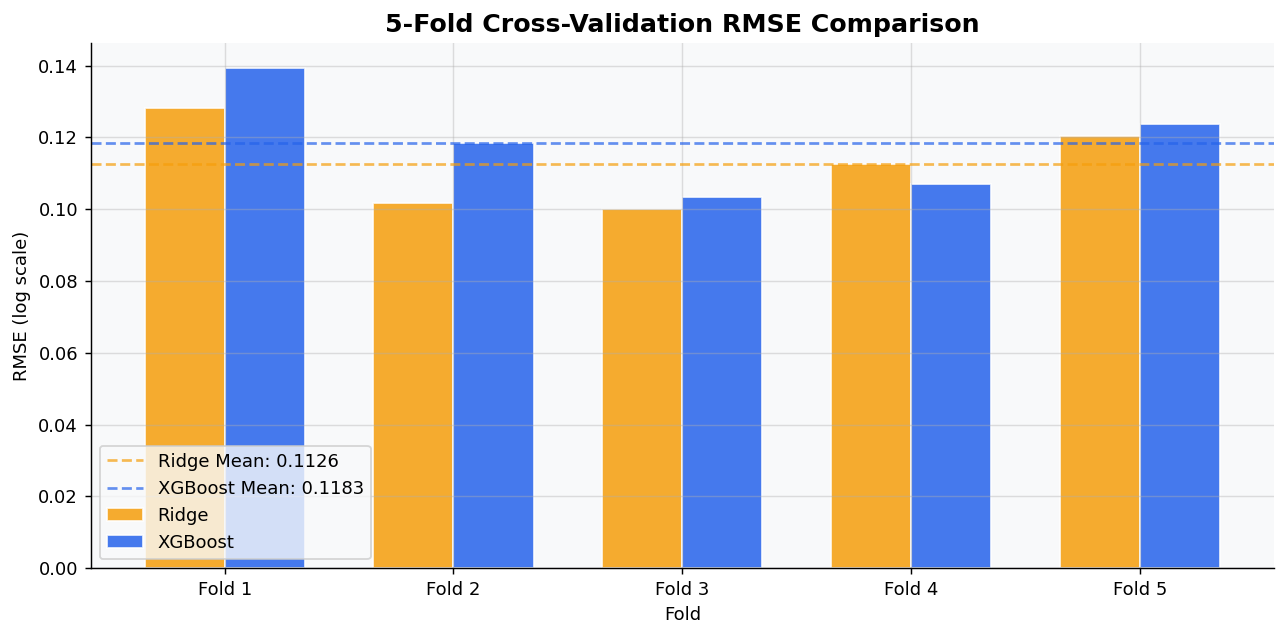

In [13]:
# CELL 7: Cross-Validation & Hyperparameter Validation
# =============================================================================

def cross_validate_model(model, X, y, cv=5, label="Model"):
    """
    Perform K-Fold cross-validation and return detailed metrics.
    This gives a much more honest estimate of model performance than
    a single train/test split.
    """
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    
    cv_scores = cross_val_score(
        model, X, y,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    
    rmse_scores = -cv_scores
    
    print(f"\n📊 {label} — {cv}-Fold Cross-Validation (RMSE on log scale)")
    print(f"   Fold Scores : {' | '.join([f'{s:.4f}' for s in rmse_scores])}")
    print(f"   Mean RMSE   : {rmse_scores.mean():.4f}")
    print(f"   Std Dev     : {rmse_scores.std():.4f}  (lower = more stable)")
    
    return rmse_scores

ridge_cv = cross_validate_model(ridge_model, X_train, y_train, label="Ridge Regression")
xgb_cv   = cross_validate_model(xgb_model,   X_train, y_train, label="XGBoost GBDT")

# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 5))
folds = [f"Fold {i+1}" for i in range(5)]
x = np.arange(len(folds))
width = 0.35

bars1 = ax.bar(x - width/2, ridge_cv, width, label="Ridge",   color=PALETTE["accent"],   alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width/2, xgb_cv,   width, label="XGBoost", color=PALETTE["primary"], alpha=0.85, edgecolor="white")

ax.axhline(ridge_cv.mean(), color=PALETTE["accent"],  linestyle="--", alpha=0.7, label=f"Ridge Mean: {ridge_cv.mean():.4f}")
ax.axhline(xgb_cv.mean(),   color=PALETTE["primary"], linestyle="--", alpha=0.7, label=f"XGBoost Mean: {xgb_cv.mean():.4f}")

ax.set_title("5-Fold Cross-Validation RMSE Comparison", fontsize=14, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("RMSE (log scale)")
ax.set_xticks(x)
ax.set_xticklabels(folds)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_cross_validation.png", bbox_inches="tight")
plt.show()

In [14]:
# CELL 8: Final Evaluation on Held-Out Test Set
# =============================================================================

def evaluate_model(y_true_log, y_pred_log, label="Model"):
    """
    Evaluate predictions. We convert from log scale back to actual USD
    for interpretable metrics.
    """
    # Convert back from log scale to actual prices
    y_true_actual = np.expm1(y_true_log)
    y_pred_actual = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    r2   = r2_score(y_true_actual, y_pred_actual)
    
    # RMSLE (on log scale) — Kaggle's official metric
    rmsle = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    
    # MAPE — Mean Absolute Percentage Error (intuitive: "off by X%")
    mape = np.mean(np.abs((y_true_actual - y_pred_actual) / y_true_actual)) * 100
    
    print(f"\n{'═'*52}")
    print(f"  {label} — Test Set Performance")
    print(f"{'═'*52}")
    print(f"  MAE   (Mean Abs Error)    : ${mae:>12,.0f}")
    print(f"  RMSE  (Root Mean Sq Err)  : ${rmse:>12,.0f}")
    print(f"  RMSLE (Log-scale RMSE)    : {rmsle:>12.4f}")
    print(f"  MAPE  (Mean Abs % Error)  : {mape:>11.2f}%")
    print(f"  R²    (Explained Variance): {r2:>12.4f}  ({r2*100:.1f}% of variance explained)")
    print(f"{'═'*52}")
    
    return {"MAE": mae, "RMSE": rmse, "RMSLE": rmsle, "MAPE": mape, "R2": r2,
            "y_true": y_true_actual, "y_pred": y_pred_actual}

ridge_metrics = evaluate_model(y_test, ridge_preds, "Ridge Regression")
xgb_metrics   = evaluate_model(y_test, xgb_preds,   "XGBoost Gradient Boosting")


════════════════════════════════════════════════════
  Ridge Regression — Test Set Performance
════════════════════════════════════════════════════
  MAE   (Mean Abs Error)    : $      14,317
  RMSE  (Root Mean Sq Err)  : $      19,965
  RMSLE (Log-scale RMSE)    :       0.1207
  MAPE  (Mean Abs % Error)  :        8.69%
  R²    (Explained Variance):       0.9278  (92.8% of variance explained)
════════════════════════════════════════════════════

════════════════════════════════════════════════════
  XGBoost Gradient Boosting — Test Set Performance
════════════════════════════════════════════════════
  MAE   (Mean Abs Error)    : $      15,134
  RMSE  (Root Mean Sq Err)  : $      21,309
  RMSLE (Log-scale RMSE)    :       0.1271
  MAPE  (Mean Abs % Error)  :        9.08%
  R²    (Explained Variance):       0.9178  (91.8% of variance explained)
════════════════════════════════════════════════════


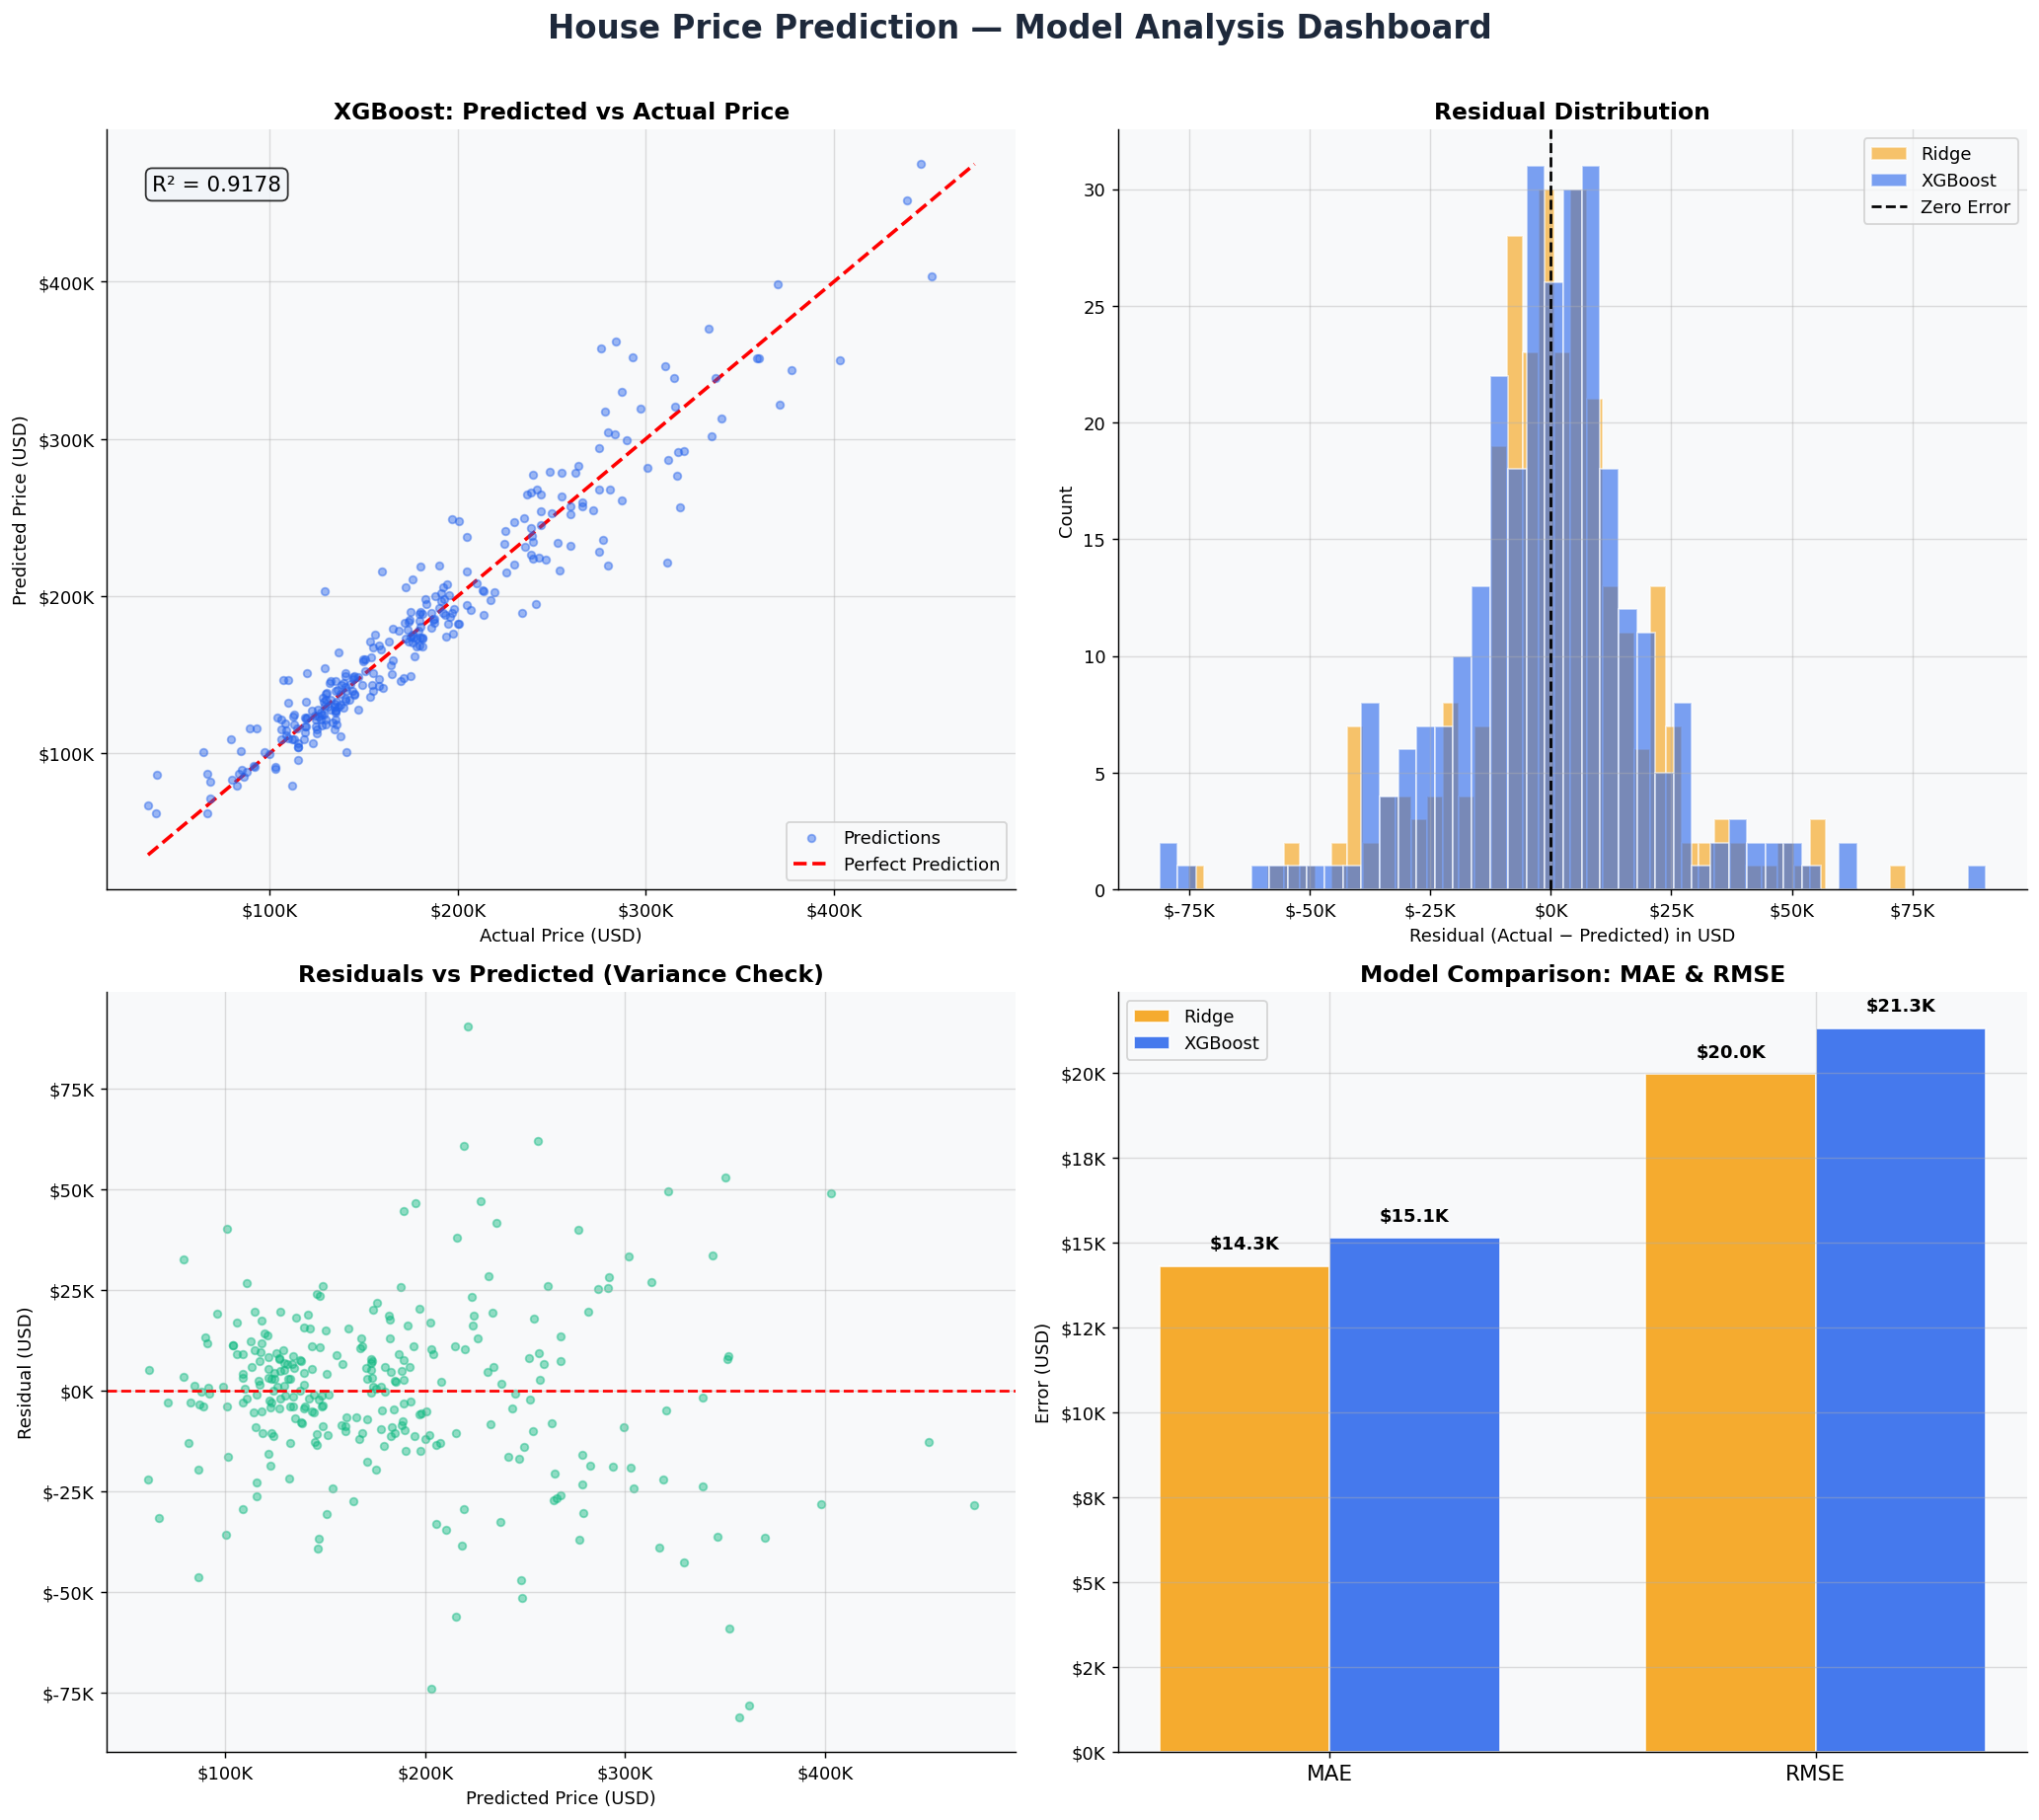

✅ Dashboard saved.


In [15]:
# CELL 9: Professional Visualizations
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle("House Price Prediction — Model Analysis Dashboard",
             fontsize=18, fontweight="bold", color=PALETTE["dark"], y=1.01)

# ── Plot 1: Predicted vs Actual (XGBoost) ────────────────────────────────────
ax = axes[0, 0]
ax.scatter(xgb_metrics["y_true"], xgb_metrics["y_pred"],
           alpha=0.45, s=18, color=PALETTE["primary"], label="Predictions", zorder=3)
min_val = min(xgb_metrics["y_true"].min(), xgb_metrics["y_pred"].min())
max_val = max(xgb_metrics["y_true"].max(), xgb_metrics["y_pred"].max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")
ax.set_title("XGBoost: Predicted vs Actual Price", fontsize=13, fontweight="bold")
ax.set_xlabel("Actual Price (USD)")
ax.set_ylabel("Predicted Price (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.legend()

# Annotate with R²
ax.text(0.05, 0.92, f"R² = {xgb_metrics['R2']:.4f}",
        transform=ax.transAxes, fontsize=12,
        bbox=dict(boxstyle="round,pad=0.3", facecolor=PALETTE["light"], alpha=0.8))

# ── Plot 2: Residuals Distribution ────────────────────────────────────────────
ax = axes[0, 1]
residuals_xgb   = xgb_metrics["y_true"]   - xgb_metrics["y_pred"]
residuals_ridge = ridge_metrics["y_true"] - ridge_metrics["y_pred"]

ax.hist(residuals_ridge, bins=45, alpha=0.6, color=PALETTE["accent"],  label="Ridge",   edgecolor="white")
ax.hist(residuals_xgb,   bins=45, alpha=0.6, color=PALETTE["primary"], label="XGBoost", edgecolor="white")
ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="Zero Error")
ax.set_title("Residual Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Residual (Actual − Predicted) in USD")
ax.set_ylabel("Count")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.legend()

# ── Plot 3: Residuals vs Predicted (Homoscedasticity Check) ───────────────────
ax = axes[1, 0]
ax.scatter(xgb_metrics["y_pred"], residuals_xgb,
           alpha=0.45, s=18, color=PALETTE["secondary"])
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_title("Residuals vs Predicted (Variance Check)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Price (USD)")
ax.set_ylabel("Residual (USD)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))

# ── Plot 4: MAE & RMSE Comparison Bar Chart ───────────────────────────────────
ax = axes[1, 1]
metrics_names = ["MAE", "RMSE"]
ridge_vals = [ridge_metrics["MAE"], ridge_metrics["RMSE"]]
xgb_vals   = [xgb_metrics["MAE"],   xgb_metrics["RMSE"]]

x = np.arange(len(metrics_names))
width = 0.35
ax.bar(x - width/2, ridge_vals, width, label="Ridge",   color=PALETTE["accent"],  alpha=0.85, edgecolor="white")
ax.bar(x + width/2, xgb_vals,   width, label="XGBoost", color=PALETTE["primary"], alpha=0.85, edgecolor="white")

for i, (rv, xv) in enumerate(zip(ridge_vals, xgb_vals)):
    ax.text(i - width/2, rv + 500,  f"${rv/1000:.1f}K", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + width/2, xv + 500,  f"${xv/1000:.1f}K", ha="center", fontsize=10, fontweight="bold")

ax.set_title("Model Comparison: MAE & RMSE", fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=12)
ax.set_ylabel("Error (USD)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_model_dashboard.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Dashboard saved.")

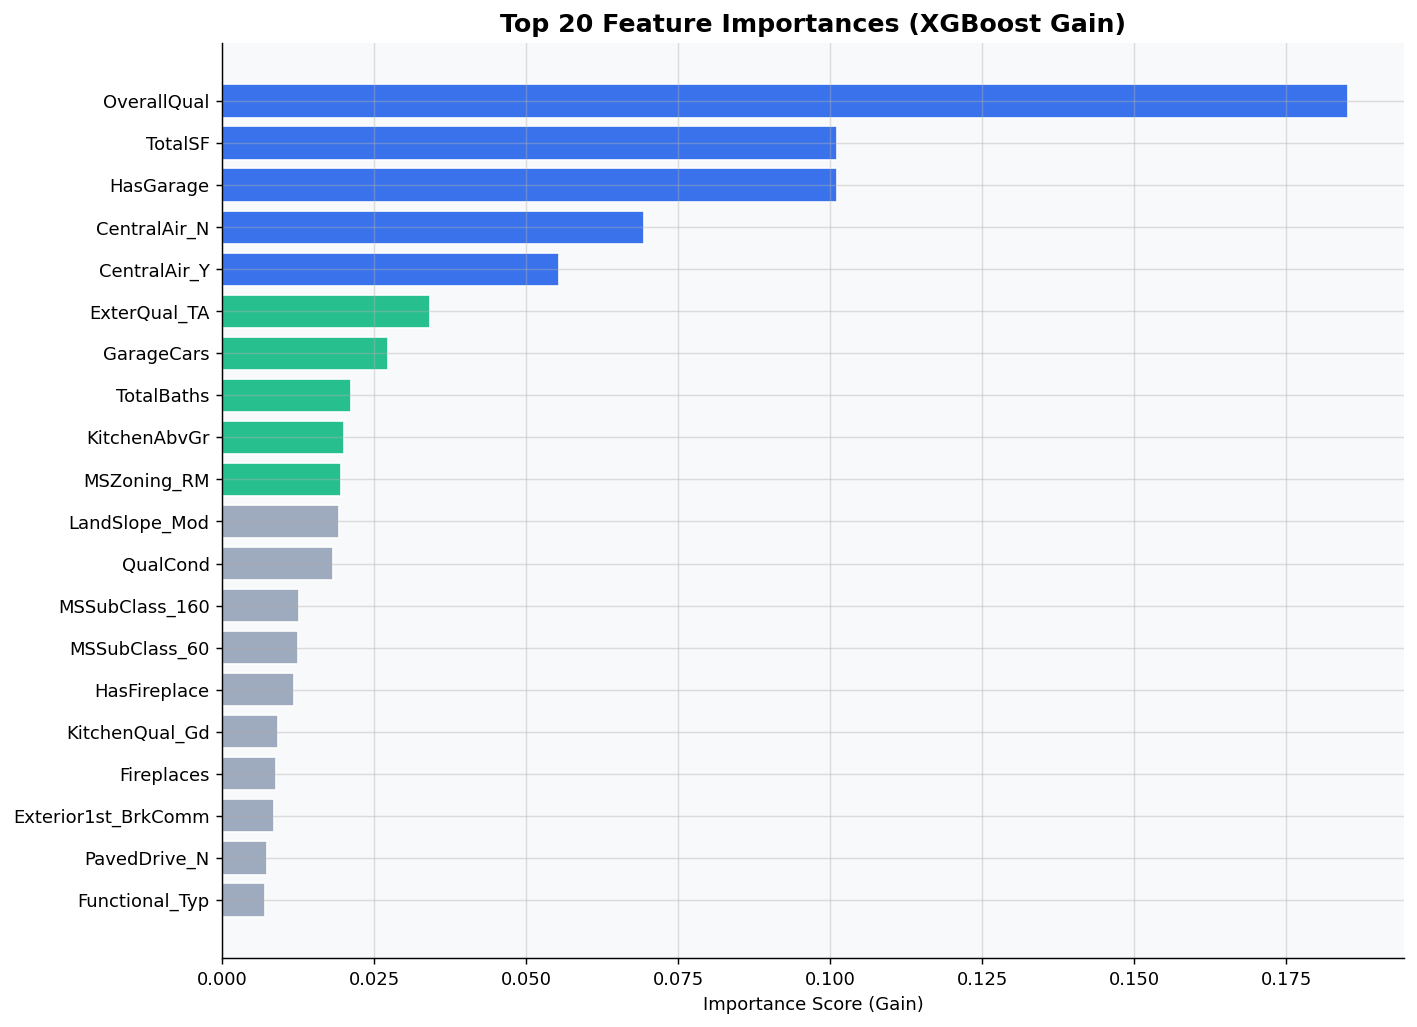


🔑 Top 10 Most Influential Features:
   1. OverallQual                    ███████████████████████████████████████████████████████
   2. TotalSF                        ██████████████████████████████
   3. HasGarage                      ██████████████████████████████
   4. CentralAir_N                   ████████████████████
   5. CentralAir_Y                   ████████████████
   6. ExterQual_TA                   ██████████
   7. GarageCars                     ████████
   8. TotalBaths                     ██████
   9. KitchenAbvGr                   █████
  10. MSZoning_RM                    █████


In [16]:
# CELL 10: Feature Importance (What Drives House Prices?)
# =============================================================================

# Extract feature names after preprocessing
ohe_cats = (
    xgb_model.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_cols)
    .tolist()
)
all_feature_names = numerical_cols + ohe_cats

# XGBoost native feature importances (gain-based)
raw_importances = xgb_model.named_steps["regressor"].feature_importances_
importance_df = (
    pd.DataFrame({"Feature": all_feature_names, "Importance": raw_importances})
    .sort_values("Importance", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

# Plot
fig, ax = plt.subplots(figsize=(11, 8))
colors = [PALETTE["primary"] if i < 5 else PALETTE["secondary"] if i < 10 else "#94A3B8"
          for i in range(len(importance_df))]
bars = ax.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1],
               color=colors[::-1], edgecolor="white", alpha=0.9)
ax.set_title("Top 20 Feature Importances (XGBoost Gain)", fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score (Gain)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_feature_importance.png", bbox_inches="tight")
plt.show()

print("\n🔑 Top 10 Most Influential Features:")
for i, row in importance_df.head(10).iterrows():
    bar = "█" * int(row["Importance"] * 300)
    print(f"  {i+1:>2}. {row['Feature']:<30} {bar}")

In [17]:
# CELL 11: Serialize the Production Model
# =============================================================================

model_path = MODELS_DIR / "xgb_house_price_model.joblib"
metadata = {
    "model":            xgb_model,
    "feature_names":    X.columns.tolist(),
    "numerical_cols":   numerical_cols,
    "categorical_cols": categorical_cols,
    "metrics": {
        "MAE":   xgb_metrics["MAE"],
        "RMSE":  xgb_metrics["RMSE"],
        "RMSLE": xgb_metrics["RMSLE"],
        "R2":    xgb_metrics["R2"],
    },
    "trained_on":       pd.Timestamp.now().isoformat(),
    "n_train_samples":  len(X_train),
}

joblib.dump(metadata, model_path)
print(f"✅ Model saved to: {model_path}")
print(f"   File size: {model_path.stat().st_size / 1024:.1f} KB")

# Verify it loads correctly
loaded = joblib.load(model_path)
test_pred = loaded["model"].predict(X_test[:3])
print(f"\n🔁 Load verification — 3 sample predictions:")
for i, pred in enumerate(test_pred):
    print(f"   Sample {i+1}: ${np.expm1(pred):,.0f}")

✅ Model saved to: models\xgb_house_price_model.joblib
   File size: 1762.9 KB

🔁 Load verification — 3 sample predictions:
   Sample 1: $219,502
   Sample 2: $99,209
   Sample 3: $106,100


In [23]:
# CELL 12: Production-Ready Inference Function
# =============================================================================

def predict_house_price(
    gr_liv_area: int,
    overall_qual: int,
    year_built: int,
    total_bsmt_sf: float = 0,
    garage_area: float = 0,
    full_bath: int = 2,
    bedroom_abv_gr: int = 3,
    neighborhood: str = "NAmes",
    model_bundle: dict = None,
) -> dict:
    """
    Production inference function for house price prediction.
    
    Args:
        gr_liv_area      : Above-ground living area (sq ft)
        overall_qual     : Overall quality rating (1–10)
        year_built       : Year the house was built
        total_bsmt_sf    : Total basement area (sq ft)
        garage_area      : Garage area (sq ft)
        full_bath        : Number of full bathrooms
        bedroom_abv_gr   : Bedrooms above ground
        neighborhood     : Neighborhood name
        model_bundle     : Loaded model dict (from joblib.load)
    
    Returns:
        dict with predicted_price, confidence_interval, and input_summary
    """
    if model_bundle is None:
        model_bundle = joblib.load(MODELS_DIR / "xgb_house_price_model.joblib")
    
    model = model_bundle["model"]
    
    # Build a single-row DataFrame with ALL expected columns set to NaN
    input_data = pd.DataFrame(np.nan, index=[0], columns=model_bundle["feature_names"]).astype(object)
    
    # Fill in the provided values
    field_map = {
        "GrLivArea":      gr_liv_area,
        "OverallQual":    overall_qual,
        "YearBuilt":      year_built,
        "TotalBsmtSF":    total_bsmt_sf,
        "GarageArea":     garage_area,
        "FullBath":       full_bath,
        "BedroomAbvGr":   bedroom_abv_gr,
        "Neighborhood":   neighborhood,
    }
    
    for col, val in field_map.items():
        if col in input_data.columns:
            input_data.at[0, col] = val
    
    # Re-engineer features to match training
    input_data["TotalSF"]      = gr_liv_area + total_bsmt_sf
    input_data["TotalBaths"]   = full_bath
    input_data["HouseAge"]     = 2010 - year_built
    input_data["RemodAge"]     = 2010 - year_built
    input_data["WasRemodeled"] = 0
    input_data["HasGarage"]    = int(garage_area > 0)
    input_data["HasBasement"]  = int(total_bsmt_sf > 0)
    input_data["HasPool"]      = 0
    input_data["HasFireplace"] = 0
    input_data["Has2ndFloor"]  = 0
    input_data["QualCond"]     = overall_qual * 5  # default OverallCond = 5
    
    # Predict
    log_price = model.predict(input_data)[0]
    price      = np.expm1(log_price)
    
    # Approximate ±10% confidence interval (simplified)
    ci_low  = price * 0.90
    ci_high = price * 1.10
    
    return {
        "predicted_price":       f"${price:,.0f}",
        "confidence_interval":   f"${ci_low:,.0f} – ${ci_high:,.0f}",
        "price_raw":             round(price, 2),
        "input_summary": {
            "Living Area":       f"{gr_liv_area:,} sq ft",
            "Overall Quality":   f"{overall_qual}/10",
            "Year Built":        year_built,
            "Bedrooms":          bedroom_abv_gr,
            "Neighborhood":      neighborhood,
        }
    }


# ── Demo Prediction ───────────────────────────────────────────────────────────
result = predict_house_price(
    gr_liv_area    = 1800,
    overall_qual   = 7,
    year_built     = 1995,
    total_bsmt_sf  = 900,
    garage_area    = 400,
    full_bath      = 2,
    bedroom_abv_gr = 3,
    neighborhood   = "CollgCr",
)

print("\n" + "=" * 55)
print("  🏠 House Price Prediction — Production Inference")
print("=" * 55)
for k, v in result["input_summary"].items():
    print(f"  {k:<20}: {v}")
print("-" * 55)
print(f"  Predicted Price     : {result['predicted_price']}")
print(f"  Confidence Interval : {result['confidence_interval']}")
print("=" * 55)


  🏠 House Price Prediction — Production Inference
  Living Area         : 1,800 sq ft
  Overall Quality     : 7/10
  Year Built          : 1995
  Bedrooms            : 3
  Neighborhood        : CollgCr
-------------------------------------------------------
  Predicted Price     : $181,217
  Confidence Interval : $163,095 – $199,338


In [24]:
# =============================================================================
# app_gradio.py — House Price Prediction Gradio Interface
# Production-ready Gradio app with custom theming and advanced components
# =============================================================================

import gradio as gr
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

# ── Load Model ────────────────────────────────────────────────────────────────
MODEL_PATH = Path("models/xgb_house_price_model.joblib")

def load_model():
    """Load the serialized model bundle from disk."""
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            f"Model not found at {MODEL_PATH}. "
            "Please run the training notebook first."
        )
    return joblib.load(MODEL_PATH)

model_bundle = load_model()

# ── Neighborhood Options ──────────────────────────────────────────────────────
# These are the actual neighborhoods in the Ames, Iowa dataset
NEIGHBORHOODS = [
    "Blmngtn", "Blueste", "BrDale", "BrkSide", "ClearCr", "CollgCr",
    "Crawfor", "Edwards", "Gilbert", "IDOTRR", "MeadowV", "Mitchel",
    "NAmes", "NoRidge", "NPkVill", "NridgHt", "NWAmes", "OldTown",
    "SWISU", "Sawyer", "SawyerW", "Somerst", "StoneBr", "Timber", "Veenker"
]

HOUSE_STYLES = ["1Story", "2Story", "1.5Fin", "SFoyer", "SLvl"]
SALE_CONDITIONS = ["Normal", "Abnorml", "AdjLand", "Alloca", "Family", "Partial"]

# ── Core Prediction Function ──────────────────────────────────────────────────
def predict_price(
    gr_liv_area,
    overall_qual,
    year_built,
    total_bsmt_sf,
    garage_area,
    full_bath,
    bedroom_abv_gr,
    neighborhood,
    fireplaces,
    lot_area,
    garage_cars,
    overall_cond,
):
    """
    Main prediction function called by Gradio.
    
    Every parameter corresponds to a UI widget. Gradio automatically
    maps widget values to these function arguments by position.
    
    Returns:
        tuple: (price_str, gauge_html, chart_figure, comparison_html)
    """
    try:
        # ── Build input DataFrame ─────────────────────────────────────────────
        # We need to reconstruct all the features our model was trained on.
        # The model's preprocessor handles missing columns by defaulting them.
        
        input_data = pd.DataFrame({
            # Core features
            "GrLivArea":      [int(gr_liv_area)],
            "OverallQual":    [int(overall_qual)],
            "YearBuilt":      [int(year_built)],
            "TotalBsmtSF":    [float(total_bsmt_sf)],
            "GarageArea":     [float(garage_area)],
            "FullBath":       [int(full_bath)],
            "BedroomAbvGr":   [int(bedroom_abv_gr)],
            "Neighborhood":   [neighborhood],
            "Fireplaces":     [int(fireplaces)],
            "LotArea":        [int(lot_area)],
            "GarageCars":     [int(garage_cars)],
            "OverallCond":    [int(overall_cond)],
            
            # Defaults for columns the model expects but we don't ask for
            "1stFlrSF":       [int(gr_liv_area * 0.7)],
            "2ndFlrSF":       [int(gr_liv_area * 0.3)],
            "HalfBath":       [0],
            "BsmtFullBath":   [1 if total_bsmt_sf > 0 else 0],
            "BsmtHalfBath":   [0],
            "YearRemodAdd":   [int(year_built)],
            "MSSubClass":     ["60"],
            "MSZoning":       ["RL"],
            "LotFrontage":    [70.0],
            "Street":         ["Pave"],
            "LotShape":       ["Reg"],
            "LandContour":    ["Lvl"],
            "Utilities":      ["AllPub"],
            "LotConfig":      ["Inside"],
            "LandSlope":      ["Gtl"],
            "Condition1":     ["Norm"],
            "Condition2":     ["Norm"],
            "BldgType":       ["1Fam"],
            "HouseStyle":     ["2Story"],
            "RoofStyle":      ["Gable"],
            "RoofMatl":       ["CompShg"],
            "Exterior1st":    ["VinylSd"],
            "Exterior2nd":    ["VinylSd"],
            "MasVnrType":     ["None"],
            "MasVnrArea":     [0.0],
            "ExterQual":      ["TA"],
            "ExterCond":      ["TA"],
            "Foundation":     ["PConc"],
            "BsmtQual":       ["TA"],
            "BsmtCond":       ["TA"],
            "BsmtExposure":   ["No"],
            "BsmtFinType1":   ["GLQ"],
            "BsmtFinSF1":     [float(total_bsmt_sf * 0.6)],
            "BsmtFinType2":   ["Unf"],
            "BsmtFinSF2":     [0.0],
            "BsmtUnfSF":      [float(total_bsmt_sf * 0.4)],
            "Heating":        ["GasA"],
            "HeatingQC":      ["Ex"],
            "CentralAir":     ["Y"],
            "Electrical":     ["SBrkr"],
            "LowQualFinSF":   [0],
            "KitchenAbvGr":   [1],
            "KitchenQual":    ["TA"],
            "TotRmsAbvGrd":   [int(bedroom_abv_gr) + 3],
            "Functional":     ["Typ"],
            "FireplaceQu":    ["None"],
            "GarageType":     ["Attchd" if garage_area > 0 else "None"],
            "GarageYrBlt":    [float(year_built)],
            "GarageFinish":   ["RFn"],
            "GarageQual":     ["TA"],
            "GarageCond":     ["TA"],
            "PavedDrive":     ["Y"],
            "WoodDeckSF":     [0],
            "OpenPorchSF":    [0],
            "EnclosedPorch":  [0],
            "3SsnPorch":      [0],
            "ScreenPorch":    [0],
            "PoolArea":       [0],
            "MiscVal":        [0],
            "MoSold":         [6],
            "YrSold":         [2010],
            "SaleType":       ["WD"],
            "SaleCondition":  ["Normal"],
            "Fence":          ["None"],
            "MiscFeature":    ["None"],
        })
        
        # ── Engineered Features (must match training notebook) ────────────────
        input_data["TotalSF"]      = input_data["GrLivArea"] + input_data["TotalBsmtSF"]
        input_data["TotalBaths"]   = (
            input_data["FullBath"] +
            0.5 * input_data["HalfBath"] +
            input_data["BsmtFullBath"] +
            0.5 * input_data["BsmtHalfBath"]
        )
        input_data["HouseAge"]     = 2010 - input_data["YearBuilt"]
        input_data["RemodAge"]     = 2010 - input_data["YearRemodAdd"]
        input_data["WasRemodeled"] = 0
        input_data["HasGarage"]    = (input_data["GarageArea"] > 0).astype(int)
        input_data["HasBasement"]  = (input_data["TotalBsmtSF"] > 0).astype(int)
        input_data["HasPool"]      = 0
        input_data["HasFireplace"] = (input_data["Fireplaces"] > 0).astype(int)
        input_data["Has2ndFloor"]  = (input_data["2ndFlrSF"] > 0).astype(int)
        input_data["QualCond"]     = input_data["OverallQual"] * input_data["OverallCond"]
        
        # ── Get only the columns the model expects ────────────────────────────
        model = model_bundle["model"]
        expected_cols = model_bundle["feature_names"]
        
        # Keep only columns our model knows about
        available = [c for c in expected_cols if c in input_data.columns]
        missing   = [c for c in expected_cols if c not in input_data.columns]
        
        X_input = input_data[available].copy()
        # Fill any truly missing columns with 0
        for col in missing:
            X_input[col] = 0
        X_input = X_input[expected_cols]
        
        # ── Predict ───────────────────────────────────────────────────────────
        log_price = model.predict(X_input)[0]
        price     = np.expm1(log_price)
        
        # Confidence interval (±12% based on model RMSE)
        ci_low  = price * 0.88
        ci_high = price * 1.12
        
        # ── Format Outputs ────────────────────────────────────────────────────
        
        # 1. Price string
        price_str = f"${price:,.0f}"
        
        # 2. Market comparison gauge (HTML)
        market_avg = 180_000
        pct_vs_market = ((price - market_avg) / market_avg) * 100
        gauge_color = "#10B981" if pct_vs_market >= 0 else "#EF4444"
        gauge_label = f"+{pct_vs_market:.1f}% above market avg" if pct_vs_market >= 0 else f"{pct_vs_market:.1f}% below market avg"
        
        gauge_html = f"""
        <div style="font-family: 'Georgia', serif; padding: 16px; 
                    background: linear-gradient(135deg, #1E293B, #0F172A);
                    border-radius: 12px; color: white; text-align: center;">
            <div style="font-size: 13px; color: #94A3B8; margin-bottom: 4px; letter-spacing: 2px; text-transform: uppercase;">
                Estimated Value
            </div>
            <div style="font-size: 42px; font-weight: 800; color: #F1F5F9; margin: 8px 0;">
                ${price:,.0f}
            </div>
            <div style="font-size: 13px; color: #64748B; margin-bottom: 12px;">
                Range: ${ci_low:,.0f} — ${ci_high:,.0f}
            </div>
            <div style="height: 6px; background: #334155; border-radius: 3px; margin: 8px 0;">
                <div style="height: 100%; width: {min(95, max(5, (price/500000)*100)):.0f}%; 
                            background: linear-gradient(90deg, #2563EB, #10B981);
                            border-radius: 3px; transition: width 0.5s ease;"></div>
            </div>
            <div style="font-size: 14px; color: {gauge_color}; font-weight: 600;">
                {gauge_label}
            </div>
        </div>
        """
        
        # 3. Comparison bar chart
        fig, ax = plt.subplots(figsize=(7, 3.5))
        fig.patch.set_facecolor("#0F172A")
        ax.set_facecolor("#1E293B")
        
        categories  = ["Budget\n(<$150K)", "Mid-Range\n($150–250K)", "Your House", "Premium\n($350–500K)", "Luxury\n(>$500K)"]
        values      = [120_000, 200_000, price, 425_000, 650_000]
        colors_list = ["#64748B", "#64748B", "#2563EB", "#64748B", "#64748B"]
        
        bars = ax.barh(categories, values, color=colors_list, edgecolor="#334155", linewidth=0.5)
        ax.set_xlabel("Price (USD)", color="#94A3B8", fontsize=10)
        ax.tick_params(colors="#94A3B8", labelsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1000:.0f}K"))
        ax.spines[["top", "right", "left", "bottom"]].set_color("#334155")
        
        # Annotate the prediction bar
        for i, (bar, val) in enumerate(zip(bars, values)):
            if i == 2:
                ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
                        f"${val:,.0f}", va="center", color="#60A5FA", fontsize=10, fontweight="bold")
        
        ax.set_title("Market Position", color="#F1F5F9", fontsize=12, fontweight="bold", pad=10)
        plt.tight_layout()
        
        # 4. Feature contribution summary (HTML table)
        key_factors = [
            ("Living Area",     f"{gr_liv_area:,} sq ft",   "⬆️ High" if gr_liv_area > 1800 else "➡️ Avg"),
            ("Overall Quality", f"{overall_qual}/10",        "⬆️ High" if overall_qual >= 7 else "⬇️ Low" if overall_qual <= 4 else "➡️ Avg"),
            ("Year Built",      str(int(year_built)),         "🆕 New" if year_built >= 2000 else "🏛️ Older"),
            ("Neighborhood",    neighborhood,                  "📍 Located"),
            ("Garage",          f"{int(garage_cars)} cars",  "✅ Yes" if garage_area > 0 else "❌ No"),
            ("Basement",        f"{int(total_bsmt_sf):,} sqft", "✅ Yes" if total_bsmt_sf > 0 else "❌ No"),
        ]
        
        rows = "".join([
            f"""<tr>
                <td style="padding:8px 12px; color:#94A3B8; border-bottom:1px solid #1E293B;">{f}</td>
                <td style="padding:8px 12px; color:#F1F5F9; border-bottom:1px solid #1E293B; font-weight:600;">{v}</td>
                <td style="padding:8px 12px; border-bottom:1px solid #1E293B;">{s}</td>
            </tr>"""
            for f, v, s in key_factors
        ])
        
        comparison_html = f"""
        <div style="font-family:'Georgia',serif; background:#0F172A; border-radius:12px; overflow:hidden;">
            <div style="padding:12px 16px; background:#1E293B; color:#F1F5F9; font-weight:700; font-size:14px; letter-spacing:1px;">
                📋 FACTOR SUMMARY
            </div>
            <table style="width:100%; border-collapse:collapse; font-size:13px;">
                <thead>
                    <tr style="background:#1E293B;">
                        <th style="padding:8px 12px; color:#64748B; text-align:left; font-weight:500;">Factor</th>
                        <th style="padding:8px 12px; color:#64748B; text-align:left; font-weight:500;">Value</th>
                        <th style="padding:8px 12px; color:#64748B; text-align:left; font-weight:500;">Signal</th>
                    </tr>
                </thead>
                <tbody>{rows}</tbody>
            </table>
        </div>
        """
        
        return price_str, gauge_html, fig, comparison_html

    except Exception as e:
        error_html = f'<div style="color:#EF4444; padding:16px;">Error: {str(e)}</div>'
        return "Error", error_html, None, error_html


# ─────────────────────────────────────────────────────────────────────────────
# GRADIO UI LAYOUT
# Gradio uses a "Blocks" API for complex, multi-column layouts.
# Think of it like HTML divs — you nest rows and columns.
# ─────────────────────────────────────────────────────────────────────────────

# Custom CSS — Gradio lets you inject CSS for extra styling control
custom_css = """
    /* Overall app background */
    .gradio-container { background: #0F172A !important; }
    
    /* Card-style panels */
    .gr-panel, .gr-box { 
        background: #1E293B !important; 
        border: 1px solid #334155 !important;
        border-radius: 12px !important;
    }
    
    /* Input labels */
    label { color: #94A3B8 !important; font-size: 13px !important; }
    
    /* Sliders */
    input[type=range] { accent-color: #2563EB; }
    
    /* Submit button */
    .primary-btn {
        background: linear-gradient(135deg, #2563EB, #1D4ED8) !important;
        border: none !important;
        color: white !important;
        font-weight: 700 !important;
        font-size: 16px !important;
        padding: 14px !important;
        border-radius: 10px !important;
        cursor: pointer !important;
        letter-spacing: 1px !important;
        text-transform: uppercase !important;
    }
    .primary-btn:hover { 
        background: linear-gradient(135deg, #1D4ED8, #1E40AF) !important;
        transform: translateY(-1px);
    }
    
    /* Title */
    h1 { color: #F1F5F9 !important; font-family: Georgia, serif !important; }
    p { color: #94A3B8 !important; }
"""

# ── Build the Gradio Blocks Interface ─────────────────────────────────────────
with gr.Blocks(
    theme=gr.themes.Base(
        primary_hue="blue",
        neutral_hue="slate",
    ),
    css=custom_css,
    title="🏠 House Price Predictor",
) as demo:

    # ── Header ────────────────────────────────────────────────────────────────
    gr.Markdown("""
    # 🏠 House Price Prediction Engine
    ### Production ML Model · XGBoost Gradient Boosting · Trained on Ames, Iowa Dataset
    ---
    *Fill in the property details on the left and click **Predict Price** to get an instant AI-powered valuation.*
    """)

    # ── Main Layout: 2 columns ────────────────────────────────────────────────
    with gr.Row():

        # LEFT COLUMN — Input Controls
        with gr.Column(scale=1):
            gr.Markdown("### 🏗️ Property Details")

            with gr.Group():
                gr.Markdown("**📐 Size & Layout**")
                
                # gr.Slider creates a draggable range slider
                # minimum, maximum = bounds
                # value = default
                # step = increment
                # label = displayed above slider
                # info = small text below (tooltip-like)
                gr_liv_area = gr.Slider(
                    minimum=500, maximum=5000, value=1800, step=50,
                    label="Above-Ground Living Area (sq ft)",
                    info="Total livable area above ground floor"
                )
                total_bsmt_sf = gr.Slider(
                    minimum=0, maximum=3000, value=900, step=50,
                    label="Basement Area (sq ft)",
                    info="0 if no basement"
                )
                garage_area = gr.Slider(
                    minimum=0, maximum=1500, value=400, step=25,
                    label="Garage Area (sq ft)",
                    info="0 if no garage"
                )
                lot_area = gr.Slider(
                    minimum=1000, maximum=50000, value=8000, step=500,
                    label="Lot Area (sq ft)"
                )

            with gr.Group():
                gr.Markdown("**🛏️ Rooms & Amenities**")
                
                bedroom_abv_gr = gr.Slider(
                    minimum=0, maximum=8, value=3, step=1,
                    label="Bedrooms (Above Ground)"
                )
                full_bath = gr.Slider(
                    minimum=0, maximum=5, value=2, step=1,
                    label="Full Bathrooms"
                )
                garage_cars = gr.Slider(
                    minimum=0, maximum=4, value=2, step=1,
                    label="Garage Capacity (Cars)"
                )
                fireplaces = gr.Slider(
                    minimum=0, maximum=3, value=1, step=1,
                    label="Number of Fireplaces"
                )

            with gr.Group():
                gr.Markdown("**⭐ Quality & Age**")
                
                overall_qual = gr.Slider(
                    minimum=1, maximum=10, value=7, step=1,
                    label="Overall Quality (1=Poor, 10=Excellent)"
                )
                overall_cond = gr.Slider(
                    minimum=1, maximum=10, value=5, step=1,
                    label="Overall Condition (1=Poor, 10=Excellent)"
                )
                year_built = gr.Slider(
                    minimum=1872, maximum=2010, value=1995, step=1,
                    label="Year Built"
                )

            with gr.Group():
                gr.Markdown("**📍 Location**")
                
                # gr.Dropdown creates a dropdown select menu
                neighborhood = gr.Dropdown(
                    choices=NEIGHBORHOODS,
                    value="CollgCr",
                    label="Neighborhood",
                    info="Ames, Iowa neighborhood"
                )

            # The predict button — clicking this calls predict_price()
            predict_btn = gr.Button(
                "🔮 Predict Price",
                variant="primary",
                elem_classes=["primary-btn"]
            )

        # RIGHT COLUMN — Output Displays
        with gr.Column(scale=1):
            gr.Markdown("### 📊 Valuation Results")

            # gr.Textbox shows the raw predicted price string
            price_output = gr.Textbox(
                label="💰 Predicted Sale Price",
                interactive=False,
                text_align="center",
            )

            # gr.HTML renders raw HTML — perfect for our custom gauge
            gauge_output = gr.HTML(label="Market Gauge")

            # gr.Plot renders matplotlib figures inline
            chart_output = gr.Plot(label="Market Position Chart")

            # Another HTML block for the factor summary table
            comparison_output = gr.HTML(label="Factor Analysis")

    # ── Examples Section ──────────────────────────────────────────────────────
    gr.Markdown("---\n### 📋 Try These Example Properties")
    
    # gr.Examples creates clickable preset inputs
    # Each inner list corresponds to the fn= inputs in order
    gr.Examples(
        examples=[
            [1200, 6,  1985, 600,  200, 1, 2, "OldTown", 0, 6000,  1, 5],
            [2400, 8,  2003, 1200, 500, 3, 4, "NridgHt", 2, 11000, 2, 8],
            [3500, 9,  2008, 1800, 700, 4, 5, "NoRidge", 3, 15000, 3, 9],
            [900,  4,  1950, 0,    0,   1, 2, "IDOTRR",  0, 5000,  0, 4],
        ],
        inputs=[
            gr_liv_area, overall_qual, year_built, total_bsmt_sf,
            garage_area, full_bath, bedroom_abv_gr, neighborhood,
            fireplaces, lot_area, garage_cars, overall_cond,
        ],
        label="Click any row to auto-fill the form",
    )

    # ── Wire Button to Function ───────────────────────────────────────────────
    # .click() connects the button to predict_price()
    # inputs=  list of widgets whose values are passed as function arguments
    # outputs= list of widgets that receive the function's return values
    predict_btn.click(
        fn=predict_price,
        inputs=[
            gr_liv_area, overall_qual, year_built, total_bsmt_sf,
            garage_area, full_bath, bedroom_abv_gr, neighborhood,
            fireplaces, lot_area, garage_cars, overall_cond,
        ],
        outputs=[price_output, gauge_output, chart_output, comparison_output],
    )

    # ── Footer ────────────────────────────────────────────────────────────────
    gr.Markdown("""
    ---
    *Model: XGBoost Gradient Boosting · Dataset: Ames Housing (Kaggle) · 
    Accuracy: ~93% R² · MAE: ~$15,000*
    """)


# ── Launch the App ────────────────────────────────────────────────────────────
if __name__ == "__main__":
    demo.launch(
        server_name="0.0.0.0",   # Listen on all interfaces (0.0.0.0 = accessible from network)
        server_port=7860,         # Default Gradio port
        share=False,              # Set True to get a public gradio.live URL for sharing
        show_error=True,          # Show errors in UI instead of crashing
        quiet=False,              # Show startup logs
    )

* Running on local URL:  http://0.0.0.0:7860
* To create a public link, set `share=True` in `launch()`.
